<a href="https://colab.research.google.com/github/AbeeraImran/GEN-AI_Seq2Seq_UrduQA/blob/final_codefile/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets sentencepiece sacrebleu rouge-score torch

In [ ]:
# cell:1
from datasets import load_dataset

ds = load_dataset("uqa/UQA")

ex = ds["train"][0]
print("Keys:", ex.keys())
print("Question:", ex["question"])
print("Answer Data:", ex.get("answer") or ex.get("answers"))

n_total = len(ds["train"])
n_ans = sum(not a["is_impossible"] for a in ds["train"])
print(f"train rows: {n_total}, answerable: {n_ans}")

Keys: dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])
Question: بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
Answer Data: 1990 کی دہائی کے آخر میں
train rows: 124745, answerable: 83018


In [ ]:
# cell:2

import csv

ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"
SENT_DELIMS = "\u06D4\u061F!"

def split_sentences(text):
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1
    if start < len(text):
        yield start, len(text), text[start:]

def make_pair(example, max_src=60, max_tgt=25):
    if example.get("is_impossible", False):
        return None

    ans_data = example.get("answer") or example.get("answers")
    start_data = example.get("answer_start")

    try:
        if isinstance(ans_data, dict):
            a_text = ans_data["text"][0]
            a_start = ans_data["answer_start"][0]
        else:
            a_text = ans_data[0] if isinstance(ans_data, list) else ans_data
            a_start = start_data[0] if isinstance(start_data, list) else start_data
    except (IndexError, KeyError, TypeError):
        return None

    context = example["context"]

    for s, e, sent in split_sentences(context):
        if s <= a_start < e:
            rel = a_start - s
            if sent[rel:rel + len(a_text)] != a_text:
                return None

            src = (sent[:rel] + " " + ANS_OPEN + " " + a_text + " "
                   + ANS_CLOSE + " " + sent[rel + len(a_text):]).strip()
            src = " ".join(src.split())
            tgt = " ".join(example["question"].split())

            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None
            return src, tgt
    return None

def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]
    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(f, delimiter="\t", quoting=csv.QUOTE_NONE, escapechar="\\")
        w.writerows(pairs)
    print(f"{out_path}: {len(pairs)} pairs")
    return pairs

train_pairs = build_split(ds["train"], "train.tsv")
valid_pairs = build_split(ds["validation"], "valid.tsv")

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


In [ ]:
# cell:3

print("source ",train_pairs[0][0])
print("target ",train_pairs[0][1])

source  ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
target  بیونس نے کب مقبولیت حاصل کرنا شروع کی؟


In [ ]:
# cell:4

import sentencepiece as spm

ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"

with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n" + tgt + "\n")

spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="ur_sp",
    vocab_size=8000,
    model_type="unigram",
    character_coverage=1.0,
    user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
PAD, UNK, BOS, EOS = 0, 1, 2, 3

src, tgt = train_pairs[0]
print("Tokens:", sp.encode(src, out_type=str))
print("IDs:", sp.encode(tgt))
print("Match Check:", sp.decode(sp.encode(tgt)) == tgt)

Tokens: ['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']
IDs: [2757, 18, 83, 2810, 100, 151, 99, 9, 11]
Match Check: True


Dataset class

In [ ]:
# cell:5

import torch
from torch.utils.data import Dataset, DataLoader

class QGDataset(Dataset):
    def __init__(self, tsv_path, sp_model):
        self.sp = sp_model
        self.pairs = []

        with open(tsv_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue

                parts = line.split('\t')
                if len(parts) == 2:
                    self.pairs.append((parts[0], parts[1]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]

        src_ids = self.sp.encode(src_text)

        tgt_ids = [2] + self.sp.encode(tgt_text) + [3]

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)

In [ ]:
# cell:6

train_dataset = QGDataset("train.tsv", sp)
print("Total dataset size:", len(train_dataset))
src_sample, tgt_sample = train_dataset[0]
print("Source tensor:", src_sample)
print("Target tensor:", tgt_sample)

Total dataset size: 75067
Source tensor: tensor([1159,   10, 2741,    8,  192,  144,   12,   21,    9, 5942,  144,   10,
          21,   18, 3923,    8,  166, 1224,   12, 3207,    7, 4386,    8, 2612,
          16,   10,   12,    6,    4, 1091,    9,  168,    7,  324,    8,    6,
           5, 1331, 6940, 1330,  751,  103,  198, 5159, 4084,    7, 2412, 3092,
           9,  403,   13, 5250,  100,  175])
Target tensor: tensor([   2, 2757,   18,   83, 2810,  100,  151,   99,    9,   11,    3])


In [ ]:
# cell:7

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Subset

def collate_fn(batch):
    src_list = [item[0] for item in batch]
    tgt_list = [item[1] for item in batch]
    src_lengths = torch.tensor([len(s) for s in src_list], dtype=torch.long)
    padded_src = pad_sequence(src_list, batch_first=True, padding_value=0)
    padded_tgt = pad_sequence(tgt_list, batch_first=True, padding_value=0)
    return padded_src, padded_tgt, src_lengths

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

valid_dataset = QGDataset("valid.tsv", sp)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
# cell:8

batch=next(iter(train_loader))

src,tgt,lengths=batch

print("source shape ",src.shape)
print("target shape ",tgt.shape)
print("lengths shape ",lengths.shape)
print("first source length ",lengths[0])
print("first source ",src[0])
print("first target ",tgt[0])

source shape  torch.Size([64, 112])
target shape  torch.Size([64, 30])
lengths shape  torch.Size([64])
first source length  tensor(54)
first source  tensor([1262,   10,    6,    4, 2483,    6,    5,   18,   47,   53, 1366,   16,
          36, 4412, 1229,    7,   24, 4300,   40, 5553,   15, 2234,   33,   13,
          67, 1276, 2802,   15, 2234,  151, 1276,   26,   19, 2119,   60,   23,
          12, 3073, 5984,   15,   20,   34, 1768,  128,    7, 1276,   12, 2882,
        3691,   15, 2234,  151, 2233,   45,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
first target  tensor([   2,   22,   18, 1366,   16,   36,   20, 3073, 4556,   20,  124,  115,
    

Encoder:

In [ ]:
# cell:9

import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class Encoder(nn.Module):
    def __init__(self, vocab_size=8000, emb_dim=256, hidden_size=512, num_layers=2, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, src, src_lengths):
        embedded = self.embedding(src)

        packed = pack_padded_sequence(
            embedded,
            src_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        outputs, (hidden, cell) = self.rnn(packed)

        outputs,_=pad_packed_sequence(
            outputs,batch_first=True,
            total_length=src.size(1)
        )
        return outputs, hidden, cell

In [ ]:
# cell:10

encoder = Encoder()

batch_src, batch_tgt, batch_lens = next(iter(train_loader))

enc_outputs, enc_hidden, enc_cell = encoder(batch_src, batch_lens)

print("Encoder Output Shape:", enc_outputs.shape)
print("Hidden State Shape:", enc_hidden.shape)
print("Cell State Shape:", enc_cell.shape)

Encoder Output Shape: torch.Size([64, 70, 1024])
Hidden State Shape: torch.Size([4, 64, 512])
Cell State Shape: torch.Size([4, 64, 512])


Decoder:

In [ ]:
# cell:11

class BahdanauAttention(nn.Module):
    def __init__(self,encoder_hidden_size=512, decoder_hidden_size=512, attention_dim=256):
        super().__init__()

        encoder_output_dim=encoder_hidden_size*2

        self.encoder_projection=nn.Linear(
            encoder_output_dim,
            attention_dim
        )

        self.decoder_projection=nn.Linear(
            decoder_hidden_size,
            attention_dim
        )

        self.energy=nn.Linear(
            attention_dim,
            1
        )

    def forward(self,decoder_hidden,encoder_outputs,mask=None):

        encoder_features=self.encoder_projection(encoder_outputs)
        decoder_features=self.decoder_projection(decoder_hidden)

        decoder_features=decoder_features.unsqueeze(1)

        combined=torch.tanh(
                encoder_features+decoder_features
            )

        energy=self.energy(combined).squeeze(2)

        if mask is not None:
                energy=energy.masked_fill(~mask,-1e10)

        attention_weights=torch.softmax(energy,dim=1)
        context=torch.bmm(
                attention_weights.unsqueeze(1),
                encoder_outputs
                ).squeeze(1)
        return context,attention_weights


class AttentionDecoder(nn.Module):
    def __init__(
        self,
        vocab_size=8000,
        emb_dim=256,
        hidden_size=512,
        num_layers=2,
        dropout=0.3,
        attention_dim=256
    ):
        super().__init__()

        self.embedding=nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=0
        )

        self.attention=BahdanauAttention(
            encoder_hidden_size=hidden_size,
            decoder_hidden_size=hidden_size,
            attention_dim=attention_dim
        )

        self.rnn=nn.LSTM(
            input_size=emb_dim+(hidden_size *2),
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.out=nn.Linear(
            hidden_size+(hidden_size*2),
            vocab_size
        )

        self.dropout=nn.Dropout(dropout)

    def forward(self,input_token,hidden,cell,encoder_outputs,mask=None):
        if input_token.dim()==2:
          input_token=input_token.squeeze(1)
        input_token=input_token.unsqueeze(1)
        embedded=self.embedding(input_token)
        embedded=self.dropout(embedded)

        decoder_hidden=hidden[-1]

        context,attention_weights=self.attention(
                decoder_hidden,
                encoder_outputs,
                mask
            )

        context=context.unsqueeze(1)
        rnn_input=torch.cat(
                (embedded,context),
                dim=2
            )

        output,(hidden,cell)=self.rnn(
                rnn_input,
                (hidden,cell)
            )

        output=output.squeeze(1)

        context=context.squeeze(1)

        prediction_input=torch.cat(
                (output,context),
                dim=1
            )

        prediction=self.out(prediction_input)
        return prediction,hidden,cell,attention_weights

training loop

In [ ]:
# cell:12

import torch
import torch.nn as nn
import torch.optim as optim
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder().to(device)
decoder = AttentionDecoder().to(device)

params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(params, lr=0.001)

criterion = nn.CrossEntropyLoss(ignore_index=0)

TEACHER_FORCING_RATIO = 0.5

def train_one_epoch(encoder, decoder, loader, optimizer, criterion):
    encoder.train()
    decoder.train()
    total_loss = 0

    for src, tgt, src_lengths in loader:
        src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
        optimizer.zero_grad()

        encoder_outputs, hidden, cell = encoder(src, src_lengths)

        batch_size, tgt_len = tgt.shape

        hidden = hidden.view(2, 2, batch_size, 512)
        hidden = hidden[:, 0, :, :] + hidden[:, 1, :, :]

        cell = cell.view(2, 2, batch_size, 512)
        cell = cell[:, 0, :, :] + cell[:, 1, :, :]

        src_mask=(torch.arange(
            src.size(1),
            device=device
        ).unsqueeze(0)<src_lengths.unsqueeze(1))

        input_token=tgt[:,0].unsqueeze(1)
        loss = 0

        for t in range(1, tgt_len):
            prediction, hidden, cell,attention_weights = decoder(input_token, hidden, cell,encoder_outputs,src_mask)
            loss += criterion(prediction, tgt[:, t])

            if random.random() < TEACHER_FORCING_RATIO:
                input_token = tgt[:, t].unsqueeze(1)
            else:
                input_token = prediction.argmax(1).unsqueeze(1)

        loss = loss / (tgt_len - 1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters())+list(decoder.parameters()),
            max_norm=1.0
        )
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
# cell:13

import torch

EPOCHS = 15
best_valid_loss = float('inf')
train_losses=[]
valid_losses=[]

def evaluate_loss(encoder, decoder, valid_loader, criterion):
    encoder.eval()
    decoder.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt, src_lengths in valid_loader:
            src, tgt = src.to(device), tgt.to(device)
            src_lengths=src_lengths.to(device)

            encoder_outputs, hidden, cell = encoder(src, src_lengths)

            batch_size, tgt_len = tgt.shape
            hidden = hidden.view(2, 2, batch_size, 512)
            hidden = hidden[:, 0, :, :] + hidden[:, 1, :, :]
            cell = cell.view(2, 2, batch_size, 512)
            cell = cell[:, 0, :, :] + cell[:, 1, :, :]

            src_mask=(
                torch.arange(
                    src.size(1),
                    device=device
                ).unsqueeze(0)<src_lengths.unsqueeze(1)
            )

            input_token = tgt[:, 0].unsqueeze(1)
            loss = 0

            for t in range(1, tgt_len):
                prediction, hidden, cell,attention_weights = decoder(input_token, hidden, cell,encoder_outputs,src_mask)
                loss += criterion(prediction, tgt[:, t])
                input_token = tgt[:, t].unsqueeze(1)

            loss = loss / (tgt_len - 1)
            epoch_loss += loss.item()

    return epoch_loss / len(valid_loader)

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(encoder, decoder, train_loader, optimizer, criterion)
    valid_loss = evaluate_loss(encoder, decoder, valid_loader, criterion)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        print("Saving new best checkpoint!")
        torch.save(
            {
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch':epoch+1,
            'train_loss':train_loss,
            'loss':valid_loss
        }, 'best_seq2seq_model.pt')


Epoch: 01 | Train Loss: 4.773 | Val Loss: 4.071
Saving new best checkpoint!
Epoch: 02 | Train Loss: 4.287 | Val Loss: 3.770
Saving new best checkpoint!
Epoch: 03 | Train Loss: 3.963 | Val Loss: 3.555
Saving new best checkpoint!
Epoch: 04 | Train Loss: 3.652 | Val Loss: 3.492
Saving new best checkpoint!
Epoch: 05 | Train Loss: 3.379 | Val Loss: 3.452
Saving new best checkpoint!
Epoch: 06 | Train Loss: 3.163 | Val Loss: 3.425
Saving new best checkpoint!
Epoch: 07 | Train Loss: 2.984 | Val Loss: 3.433
Epoch: 08 | Train Loss: 2.875 | Val Loss: 3.443
Epoch: 09 | Train Loss: 2.744 | Val Loss: 3.452
Epoch: 10 | Train Loss: 2.645 | Val Loss: 3.477
Epoch: 11 | Train Loss: 2.542 | Val Loss: 3.483
Epoch: 12 | Train Loss: 2.456 | Val Loss: 3.508
Epoch: 13 | Train Loss: 2.401 | Val Loss: 3.511
Epoch: 14 | Train Loss: 2.345 | Val Loss: 3.546
Epoch: 15 | Train Loss: 2.288 | Val Loss: 3.574


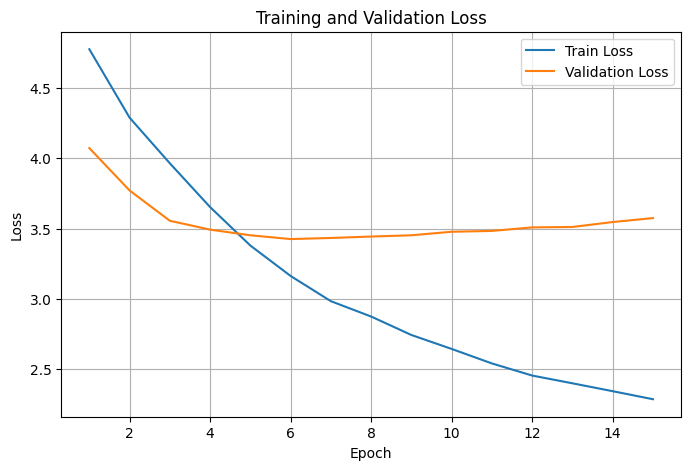

In [ ]:
# cell:14

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("training_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import os

print(os.path.exists("best_seq2seq_model.pt"))

True


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#cell:15

import torch

checkpoint=torch.load('best_seq2seq_model.pt',
                      map_location=device

                      )
encoder.load_state_dict(checkpoint["encoder_state_dict"])
decoder.load_state_dict(checkpoint["decoder_state_dict"])

encoder.eval()
decoder.eval()
print("model loaded")

model loaded


In [ ]:
#cell:16
import numpy as np

UNK_ID = 1
BOS, EOS = 2, 3

def generate_question(src_text, encoder, decoder, sp, max_len=25):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        src_ids = sp.encode(src_text)
        src = torch.tensor([src_ids], dtype=torch.long, device=device)

        src_len = len(src_ids)
        src_lengths = torch.tensor([src_len], dtype=torch.long, device=device)

        src_mask = (torch.arange(src.size(1), device=device).unsqueeze(0) < src_lengths.unsqueeze(1))

        encoder_outputs, hidden, cell = encoder(src, src_lengths)
        hidden = hidden.view(2, 2, 1, 512)
        hidden = hidden[:, 0, :, :] + hidden[:, 1, :, :]
        cell = cell.view(2, 2, 1, 512)
        cell = cell[:, 0, :, :] + cell[:, 1, :, :]

        input_token = torch.tensor([[BOS]], dtype=torch.long, device=device)
        output_ids = []
        unk_count = 0
        attn_matrix = []

        for _ in range(max_len):
            prediction, hidden, cell, attn = decoder(input_token, hidden, cell, encoder_outputs, src_mask)

            prediction[0, UNK_ID] = float('-inf')

            next_id = prediction.argmax(-1).item()
            if next_id == EOS:
                break
            if next_id == UNK_ID:
                unk_count += 1

            attn_matrix.append(attn.squeeze(0).cpu().numpy())
            output_ids.append(next_id)
            input_token = torch.tensor([[next_id]], dtype=torch.long, device=device)

        attn_matrix = np.array(attn_matrix) if len(attn_matrix) > 0 else np.empty((0, src_len))

        return sp.decode(output_ids), unk_count, len(output_ids), attn_matrix, output_ids

In [ ]:
# cell:17

def plot_attention(src_tokens, output_tokens, attn_matrix, title=""):
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.imshow(attn_matrix, cmap='viridis')

    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90)

    ax.set_yticks(range(len(output_tokens)))
    ax.set_yticklabels(output_tokens)


    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"attention_{title}.png", dpi=200)
    plt.show()

In [ ]:
# cell:18

import random

hypotheses = []
references = []
total_unk = 0
total_tokens = 0

sample_indices = random.sample(range(len(valid_pairs)), 500)
for i in sample_indices:
    src_text, ref_text = valid_pairs[i]
    hyp_text, unk_c, n_tok, attn, out_ids = generate_question(src_text, encoder, decoder, sp)
    hypotheses.append(hyp_text)
    references.append(ref_text)
    total_unk += unk_c
    total_tokens += n_tok


In [ ]:
# cell:19

for idx in [5, 42, 100]:
    src_text, ref_text = valid_pairs[idx]
    pos = src_text.find("<ans>")
    print(idx, "-> <ans> position:", pos, "/ total length:", len(src_text))

5 -> <ans> position: 50 / total length: 143
42 -> <ans> position: 34 / total length: 128
100 -> <ans> position: 104 / total length: 212


/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"attention_{title}.png", dpi=200)
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(f"attention_{title}.png", dpi=200)
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing fr

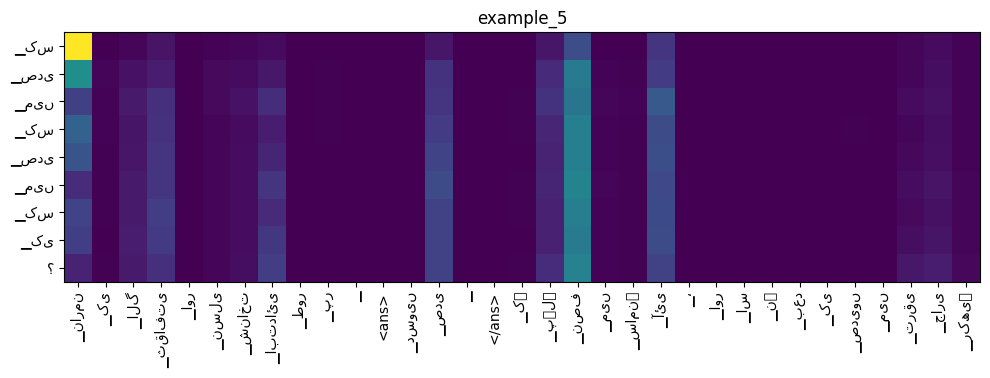

/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"attention_{title}.png", dpi=200)
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(f"attention_{title}.png", dpi=200)
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing fr

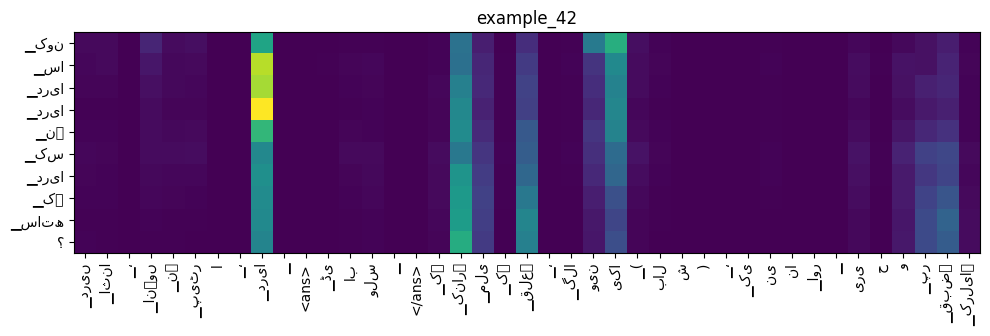

/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:23: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"attention_{title}.png", dpi=200)
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(f"attention_{title}.png", dpi=200)
/tmp/ipykernel_28327/1773066452.py:24: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing fr

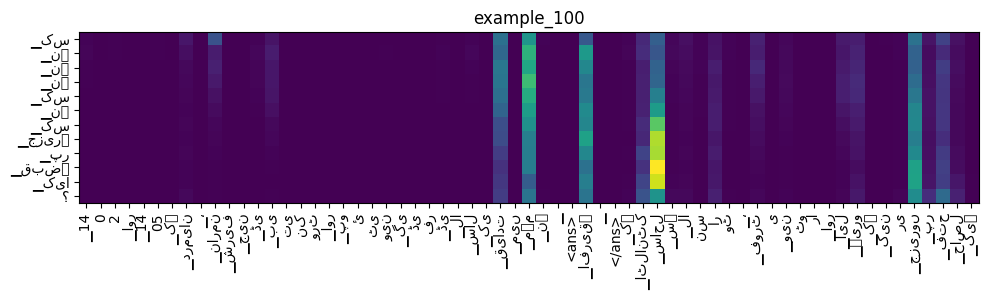

In [ ]:
# cell:20

example_indices = [5, 42, 100]

for idx in example_indices:
    src_text, ref_text = valid_pairs[idx]
    hyp_text, unk_c, n_tok, attn, out_ids = generate_question(src_text, encoder, decoder, sp)

    src_tokens = sp.encode(src_text, out_type=str)
    out_tokens = [sp.id_to_piece(i) for i in out_ids]

    plot_attention(src_tokens, out_tokens, attn, title=f"example_{idx}")

**UNK rate, ROUGE-L, BLUE-4**

In [ ]:
# cell:21

import sacrebleu

unk_rate = (total_unk / total_tokens) * 100 if total_tokens > 0 else 0.0

from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
total_fmeasure = 0
for ref, hyp in zip(references, hypotheses):
    total_fmeasure += scorer.score(ref, hyp)['rougeL'].fmeasure

average_rouge_l = total_fmeasure / len(references)

bleu = sacrebleu.corpus_bleu(hypotheses, [references])

print("=== FINAL METRICS ===")
print(f"UNK Rate: {unk_rate:.2f}%")
print(f"BLEU-4 Score: {bleu.score:.2f}")
print(f"ROUGE-L F-Measure: {average_rouge_l:.4f}")

=== FINAL METRICS ===
UNK Rate: 0.00%
BLEU-4 Score: 3.04
ROUGE-L F-Measure: 0.0063


**50 qualitative examples**

In [ ]:
import pandas as pd

csv_data = []

print("Generating 50 perfectly aligned rows for the CSV export...")

for i in range(50):
    src_text, ref_text = valid_pairs[i]

    hyp_text, unk_c, n_tok, attn, out_ids = generate_question(src_text, encoder, decoder, sp)

    ans_start = src_text.find('<ans>') + 5
    ans_end = src_text.find('</ans>')
    target_answer = src_text[ans_start:ans_end].strip() if '<ans>' in src_text and '</ans>' in src_text else "N/A"

    clean_context = src_text.replace('<ans>', '').replace('</ans>', '').strip()

    csv_data.append({
        'Context Paragraph': clean_context,
        'Target Answer': target_answer,
        'Reference Question': ref_text,
        'Generated Question': hyp_text,
        'Fluency (1-5)': '',
        'Relevance (1-5)': '',
        'Answerability (1-5)': ''
    })

df_eval = pd.DataFrame(csv_data)
df_eval.to_csv("human_evaluation_50.csv", index=False, encoding="utf-8-sig")

print("csv file created :)")

Generating 50 perfectly aligned rows for the CSV export...
csv file created :)


In [ ]:
df = pd.read_csv("human_evaluation_50.csv")

df['Target Answer'] = df['Context Paragraph'].str.extract(r'<ans>(.*?)</ans>')

df['Context Paragraph'] = df['Context Paragraph'].str.replace(r'<ans>|</ans>', ' ', regex=True)

df.to_csv("human_evaluation_50_fixed.csv", index=False, encoding="utf-8-sig")